# Computing Tempered Energy 

We aim to implement a parallel tempering scheme for annealed MCMC as per Du et al.'s [2024 paper](https://arxiv.org/pdf/2302.11552) on compositional generation with energy-based diffusion. In order to implement parallel tempering into the sampling regime of annealed MCMC, we aim to evaluate the difference between true tempered energy and our approximations.

Training follows standard DDPM noise-matching objective

### Setup

In [1]:
from src.eval import ladder_ddpm, plot_acceptance_over_time, plot_acceptance_over_position

### Sample

Note that function `plot_samples_grid` will take in a list of methods and dataset names and plot them in a grid. Function `samples_tuning` will take in a single method (ULA or MALA) and dataset name, as well as a list `step_scales_list` and `n_langevin_steps_list` and output a grid of samples for each hyperparameter. 

f avg: 0.0006
f std: 0.0010
Time 90: Swap 2.0 and 3.0 tsr diff -0.0011974573135375977 mean acceptance 0.9999985694885254
We swap 3.0 and 2.0 with acceptance 1.00
f avg: 0.0013
f std: 0.0022
Time 80: Swap 3.0 and 4.0 tsr diff -0.0028301477432250977 mean acceptance 0.9999988675117493
We swap 4.0 and 3.0 with acceptance 1.00
f avg: 0.0068
f std: 0.0113
Time 80: Swap 1.0 and 2.0 tsr diff -0.01647663116455078 mean acceptance 0.9999963641166687
We swap 2.0 and 1.0 with acceptance 1.00
f avg: 0.0086
f std: 0.0150
Time 75: Swap 2.0 and 3.0 tsr diff -0.009320735931396484 mean acceptance 0.9999951124191284
We swap 3.0 and 2.0 with acceptance 1.00
f avg: 0.0064
f std: 0.0128
Time 65: Swap 3.0 and 4.0 tsr diff -0.010774612426757812 mean acceptance 0.9999973773956299
We swap 4.0 and 3.0 with acceptance 1.00
f avg: 0.0145
f std: 0.0306
Time 65: Swap 1.0 and 2.0 tsr diff -0.0581667423248291 mean acceptance 0.9999995827674866
We swap 2.0 and 1.0 with acceptance 1.00
f avg: 0.0180
f std: 0.0411
Time 60

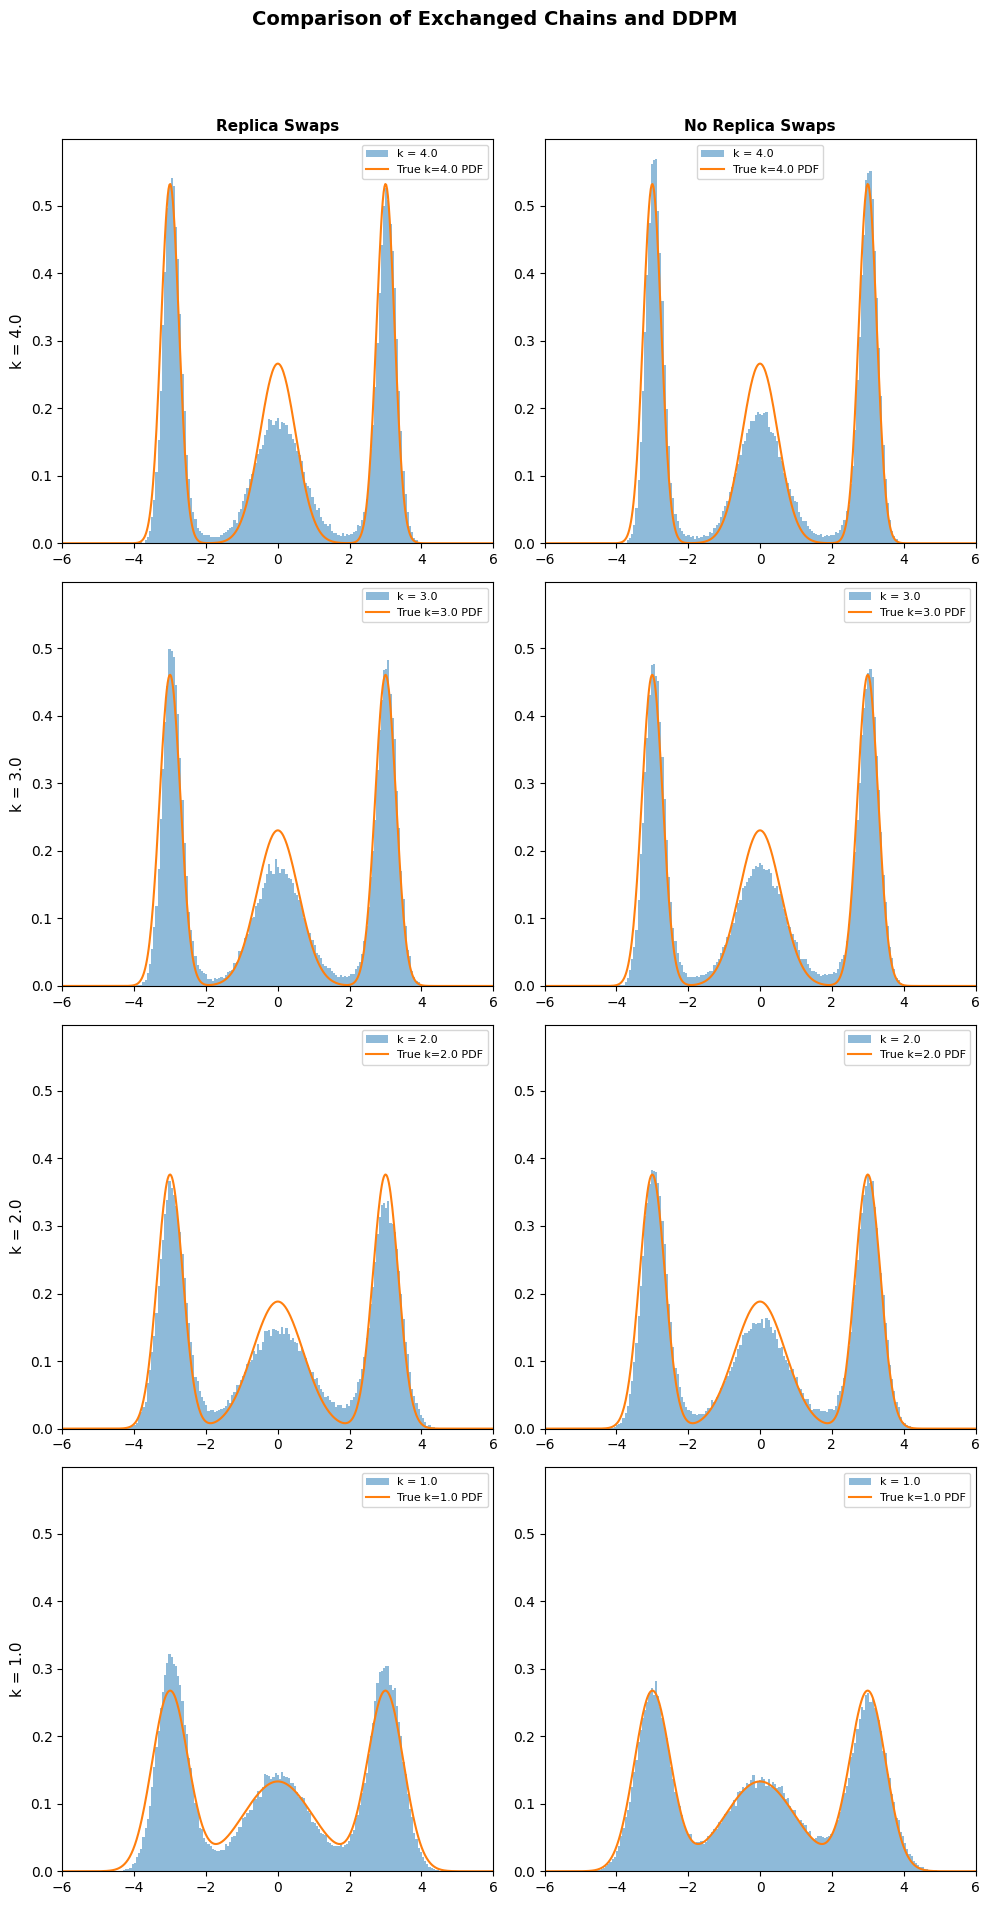

/n/netscratch/kempner_undergrads/Everyone/zwu/parallel_toy/src/eval.py:148: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


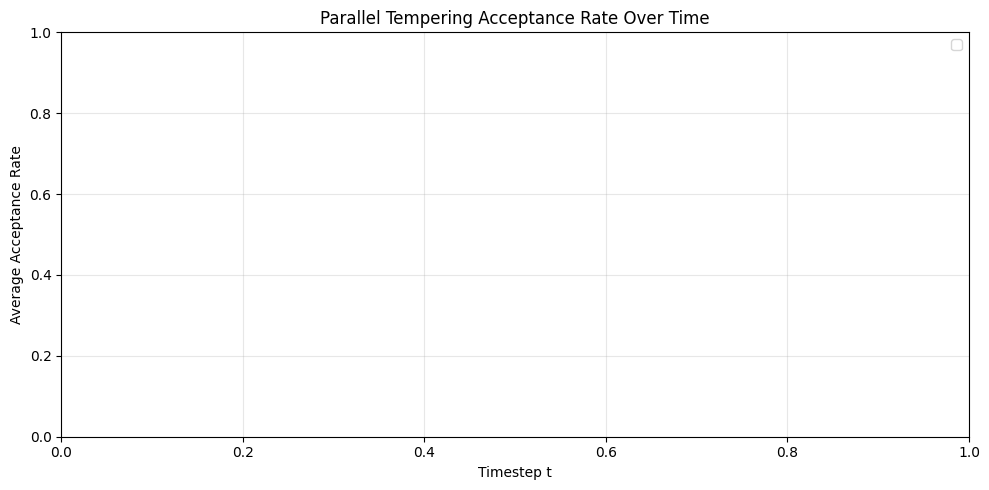

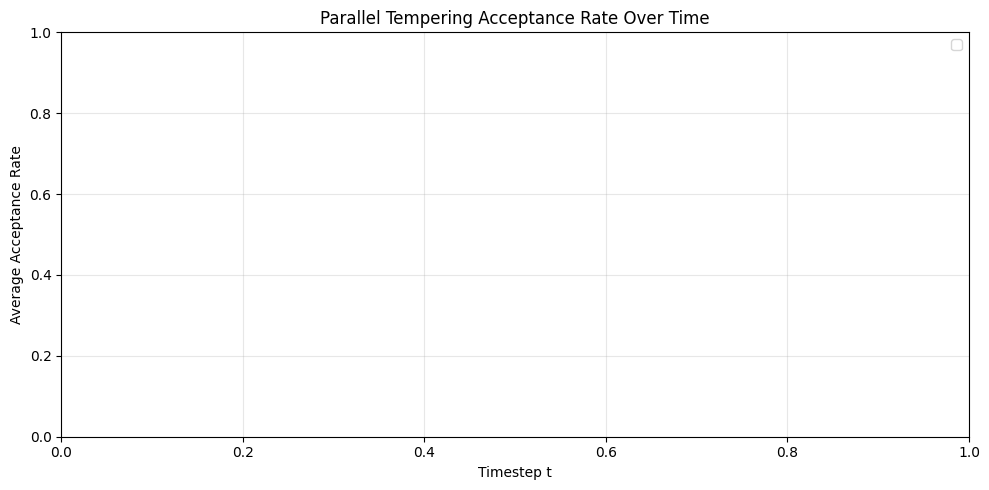

In [2]:
dataset_name = "composed"
k = 4.0
sigma = 0.6
step_scale = 1
n_langevin_steps = 0
n_replicas = 4

x_ladder, a_ladder = ladder_ddpm(dataset_name, k, sigma, step_scale, n_langevin_steps, n_replicas, x_limit=6, save_dir="figures", figsize_per_panel=(5,4), filename=None)
plot_acceptance_over_time(a_ladder)
# _ = plot_acceptance_over_position(a_ladder, x_ladder[0][k])

92,
87,
84,
81,
79,
76,
74,
72,
70,


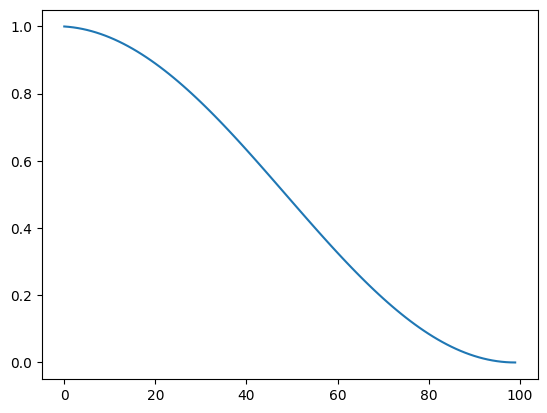

In [3]:
import matplotlib.pyplot as plt
from src.schedule import alpha_bars
import torch

targets = [0.975, 0.95, 0.925, 0.9, 0.875, 0.85, 0.825, 0.8, 0.775]
for target in targets:
    idx = (alpha_bars.cpu() - target).abs().argmin().item()
    print(f"{100-idx},")

plt.plot(alpha_bars.cpu().numpy())
plt.show()